In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from numpy.polynomial.polynomial import Polynomial
from scipy.optimize import curve_fit

In [2]:
# F_Data is a Matrix, each row is a time series
Z_Data = np.load("Z.npy")
t = np.arange(0,4097,1)
t_list = [ i for i in range(0,4097,1)]


In [3]:
def detrended_fluctuation_analysis(time_series, min_scale=4, max_scale=4096, num_scales=20, order=1):
    N = len(time_series)

    # Compute profile
    mean_x = np.mean(time_series)
    Y = np.cumsum(time_series - mean_x)

    # Define scales
    scales = np.logspace(np.log10(min_scale), np.log10(max_scale), num_scales, dtype=int)
    F = []

    # Loop over scales
    for s in scales:
        segments = N // s
        rms = []

        for i in range(segments):
            idx = slice(i * s, (i + 1) * s)
            segment = Y[idx]
            x = np.arange(len(segment))

            # Fit polynomial trend of the LOCAL TREND
            m,c = np.polyfit(x, segment, order)
            trend = (m * x) + c

            # Compute RMS OF LOCAL FLUCTUATIONS
            fluctuation = np.sqrt(np.mean((segment - trend) ** 2))
            rms.append(fluctuation)

        # Compute RMS MEAN
        F.append(np.sqrt(np.mean(np.array(rms)**2)))

    # Fit scaling exponent
    scales = np.array(scales)
    F = np.array(F)     # F is the RMS MEAN
    coeffs = np.polyfit(np.log(scales), np.log(F), 1)
    alpha = coeffs[0]
    
    return scales, F, coeffs, alpha

In [4]:
#Data Generation
idx = 0
for j in range(5):
    for i in range(20):
        scales, F, coeffs, alpha = detrended_fluctuation_analysis(Z_Data[idx], min_scale=4, max_scale=4096, num_scales=20, order=1)
        np.save(f'scalesZ{idx}.npy', scales)
        np.save(f'rmsmeanZ{idx}.npy', F)
        np.save(f'coeffsZ{idx}.npy', coeffs)
        np.save(f'alphaZ{idx}.npy', alpha)
        print('done saving...')
        idx += 1

done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done saving...
done savin

C:\Users\rjnar\AppData\Local\Temp\ipykernel_22836\1056906882.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


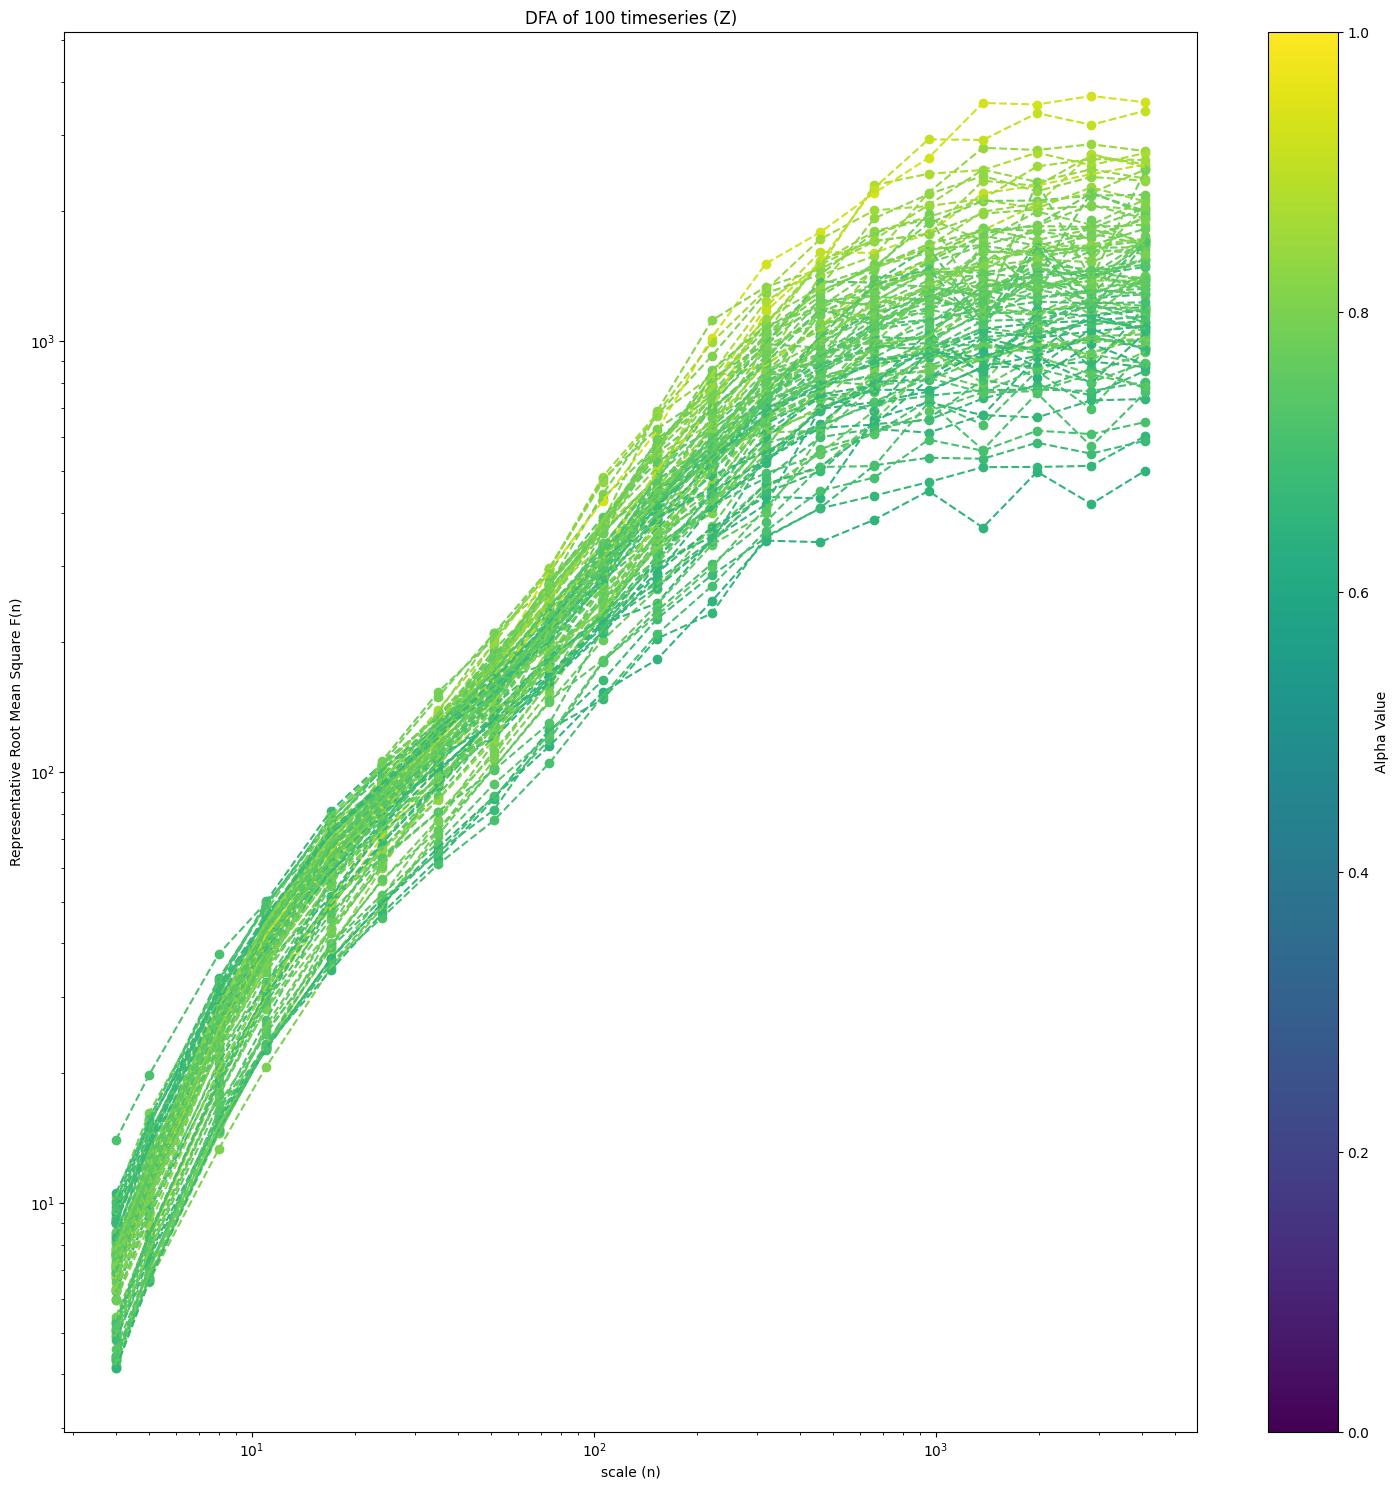

In [5]:
# Plotting
cmap = cm.get_cmap('viridis')
fig, axs = plt.subplots( figsize = (15,15))
idx = 0

for i in range(100):
    scales = np.load(f'scalesZ{idx}.npy')
    F = np.load(f'rmsmeanZ{idx}.npy')
    coeffs = np.load(f'coeffsZ{idx}.npy')
    alpha = np.load(f'alphaZ{idx}.npy')


    color = cmap(alpha)
    axs.scatter(scales, F, color=color, label='Fluctuation function')
    axs.plot(scales, F, '--' , color=color)
    #axs.plot(scales, np.exp(coeffs[1]) * scales ** alpha, '--', label=f'Fit (α={alpha:.2f})', color='r')
    idx += 1

axs.set_xscale('log')
axs.set_yscale('log')
axs.set_xlabel('scale (n)')
axs.set_ylabel("Representative Root Mean Square F(n)")
axs.set_title(f'DFA of 100 timeseries (Z)')  # Fixed method
    

plt.tight_layout()

sm = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=1))
cbar = plt.colorbar(sm, ax=axs)
cbar.set_label('Alpha Value')

plt.savefig("DFA for Z.png", dpi=72)


In [4]:
n = 4097  # Number of time steps
dt = 1  # Time step size
sigma = 1  # Standard deviation of noise

# Generate Brownian noise (Wiener process)
np.random.seed(42)  # For reproducibility
white_noise = np.random.normal(0, sigma * np.sqrt(dt), n)
brownian = np.cumsum(white_noise)  # Cumulative sum to create Brownian motion


# Generate white noise using uniform random numbers and standardize
white_noise = np.random.random(n)  # Uniform distribution [0,1)
white_noise = (white_noise - np.mean(white_noise)) / np.std(white_noise)  # Standardize to mean 0, std 1


dataset = [F_Data[0], brownian, white_noise]


In [5]:
print(len(dataset[0]))

4097


In [35]:
def sigmoid(x, L, x0, k):
    return L / (1 + np.exp(-k * (x - x0)))

def DFAn(time_series, min_scale=4, max_scale=4096, num_scales=20, order=1):
    N = len(time_series)

    # Compute profile
    mean_x = np.mean(time_series)
    Y = np.cumsum(time_series - mean_x)

    # Define scales
    scales = np.logspace(np.log10(min_scale), np.log10(max_scale), num_scales, dtype=int)
    F = []

    # Loop over scales
    for s in scales:
        segments = N // s
        rms = []

        for i in range(segments):
            idx = slice(i * s, (i + 1) * s)
            segment = Y[idx]
            x = np.arange(len(segment))

            # Fit polynomial trend of the LOCAL TREND
            m,c = np.polyfit(x, segment, order)
            trend = (m * x) + c

            # Compute RMS OF LOCAL FLUCTUATIONS
            fluctuation = np.sqrt(np.mean((segment - trend) ** 2))
            rms.append(fluctuation)

        # Compute RMS MEAN
        F.append(np.sqrt(np.mean(np.array(rms)**2)))

    x_data = scales  # Scale (n) values
    y_data = F  # Root Mean Square F(n) values

    # Apply log10 transformation to x_data (since the plot is in log-log space)
    log_x_data = np.log10(x_data)

    # Fit the sigmoid function to the log-transformed x_data
    popt, _ = curve_fit(sigmoid, log_x_data, y_data, p0=[max(y_data), np.median(log_x_data), 1])

    # Generate fitted curve
    x_fit = np.logspace(np.log10(min(x_data)), np.log10(max(x_data)), 100)
    y_fit = sigmoid(np.log10(x_fit), *popt)
    
    return scales, F, x_fit, y_fit, popt

def detrended_fluctuation_analysis(time_series, min_scale=4, max_scale=4096, num_scales=20, order=1):
    N = len(time_series)

    # Compute profile
    mean_x = np.mean(time_series)
    Y = np.cumsum(time_series - mean_x)

    # Define scales
    scales = np.logspace(np.log10(min_scale), np.log10(max_scale), num_scales, dtype=int)
    F = []

    # Loop over scales
    for s in scales:
        segments = N // s
        rms = []

        for i in range(segments):
            idx = slice(i * s, (i + 1) * s)
            segment = Y[idx]
            x = np.arange(len(segment))

            # Fit polynomial trend of the LOCAL TREND
            m,c = np.polyfit(x, segment, order)
            trend = (m * x) + c

            # Compute RMS OF LOCAL FLUCTUATIONS
            fluctuation = np.sqrt(np.mean((segment - trend) ** 2))
            rms.append(fluctuation)

        # Compute RMS MEAN
        F.append(np.sqrt(np.mean(np.array(rms)**2)))

    # Fit scaling exponent
    scales = np.array(scales)
    F = np.array(F)     # F is the RMS MEAN
    coeffs = np.polyfit(np.log(scales), np.log(F), 1)
    alpha = coeffs[0]
    
    return scales, F, coeffs, alpha

[946.16213089   2.25498142   3.62848802]


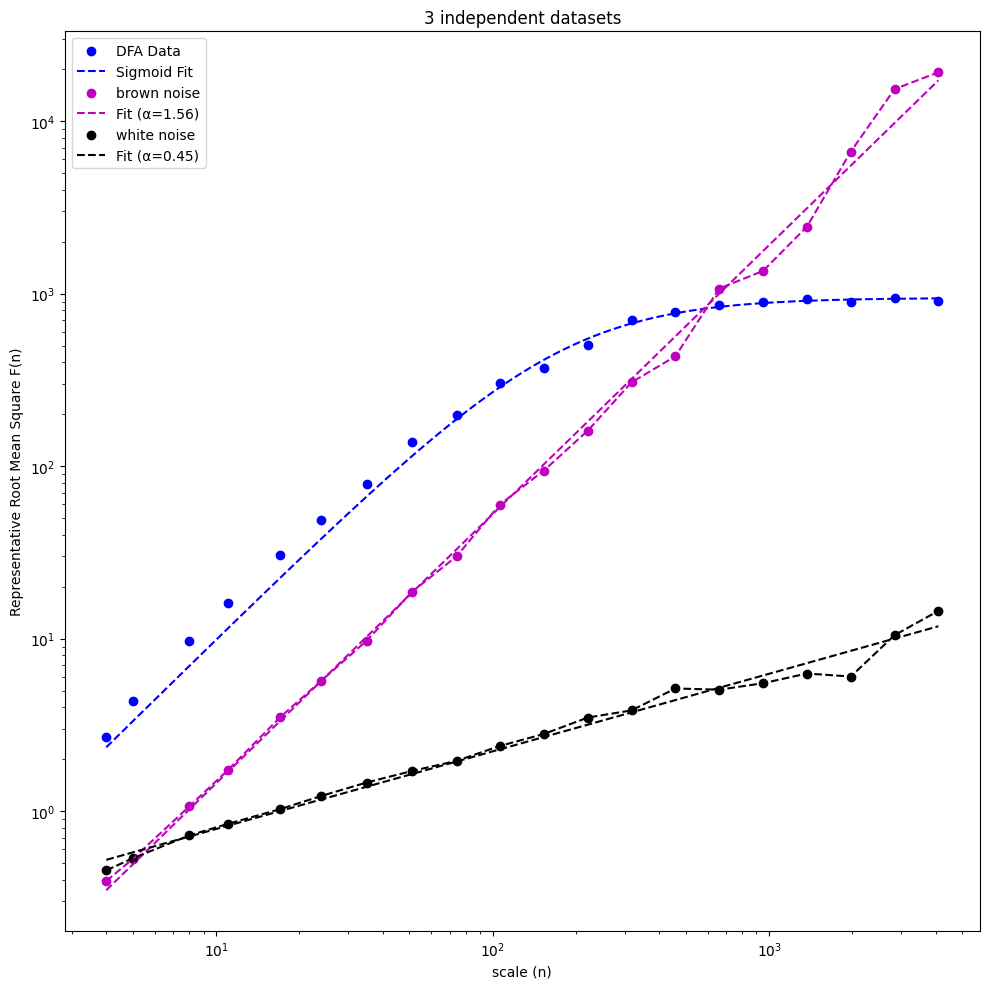

In [36]:
color = ['b','m','k']
names = ['EEG Data','brown noise','white noise']
fig , axs = plt.subplots(figsize = (10,10))

scales, F, x_data, y_data, popt = DFAn(dataset[0], min_scale=4, max_scale=4096, num_scales=20, order=1)


axs.scatter(scales, F, label="DFA Data", color="blue")
axs.plot(x_fit, y_fit, '--', label="Sigmoid Fit", color=color[0])
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_xlabel('scale (n)')
axs.set_ylabel("Representative Root Mean Square F(n)")
axs.set_title(f'3 independent datasets')  # Fixed method


for i in range(1,3):
    scales, F, coeffs, alpha = detrended_fluctuation_analysis(dataset[i], min_scale=4, max_scale=4096, num_scales=20, order=1)

    axs.scatter(scales, F, color=color[i], label=names[i])
    axs.plot(scales, F, '--' , color=color[i])
    axs.plot(scales, np.exp(coeffs[1]) * scales ** alpha, '--', label=f'Fit (α={alpha:.2f})', color=color[i])
    axs.set_xscale('log')
    axs.set_yscale('log')
    axs.set_xlabel('scale (n)')
    axs.set_ylabel("Representative Root Mean Square F(n)")
    axs.set_title(f'3 independent datasets')  # Fixed method
    axs.legend()
    

plt.tight_layout()
plt.savefig('DFAs.png', dpi=100)

print(popt)


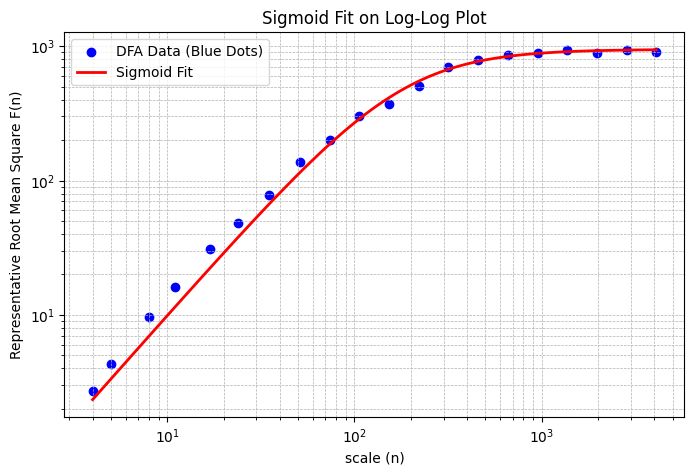

In [27]:
scales, F, x_fit , y_fit = DFAs(dataset[0], min_scale=4, max_scale=4096, num_scales=20, order=1)

# Define the sigmoid function
def sigmoid(x, L, x0, k):
    return L / (1 + np.exp(-k * (x - x0)))

# Assume you have extracted the (x, y) data for the blue dots
# Replace these arrays with your actual data
x_data = scales  # Scale (n) values
y_data = F  # Root Mean Square F(n) values

# Apply log10 transformation to x_data (since the plot is in log-log space)
log_x_data = np.log10(x_data)

# Fit the sigmoid function to the log-transformed x_data
popt, _ = curve_fit(sigmoid, log_x_data, y_data, p0=[max(y_data), np.median(log_x_data), 1])

# Generate fitted curve
x_fit = np.logspace(np.log10(min(x_data)), np.log10(max(x_data)), 100)
y_fit = sigmoid(np.log10(x_fit), *popt)

# Plot the results
plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, label="DFA Data (Blue Dots)", color='blue')
plt.plot(x_fit, y_fit, label="Sigmoid Fit", color='red', linewidth=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('scale (n)')
plt.ylabel('Representative Root Mean Square F(n)')
plt.title('Sigmoid Fit on Log-Log Plot')
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.show()
